# Fase 3 — Selección del algoritmo de clasificación

Compara 4 familias de clasificadores (mínimo exigido: 3) sobre **E2 — la representación unida** de la Fase 2, discutiendo la compatibilidad algoritmo-representación para cada una, con hiperparámetros ajustados vía `GridSearchCV` en validación cruzada estratificada, balanceo de clases **dentro de cada fold** (nunca antes de dividir), selección por macro-F1, y evaluación de test una sola vez con incertidumbre reportada (IC bootstrap).


In [4]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from nltk import TweetTokenizer

from logic.text_processing import TextProcessing
from logic.feature_extraction import FeatureExtraction

SEED = 42
np.random.seed(SEED)


## 1. Carga de datos y adaptador léxico (igual que en la Fase 2)

In [5]:
FEATURE_NAMES_ORIGINALES = [
    "weighted_position", "weighted_normalized", "label_mention", "label_url", "label_hashtag",
    "label_emoji", "label_retweets", "lexical_diversity", "label_word",
    "first_person_singular", "second_person_singular", "third_person_singular",
    "first_person_plurar", "second_person_plurar", "third_person_plurar",
    "avg_word", "kur_word", "skew_word",
    "adverb_neg", "adverb_time", "adverb_place", "adverb_mode", "adverb_cant", "adverb_all",
    "adjetives_neg", "adjetives_pos", "who_general", "who_male", "who_female",
]
EXCLUIDAS_FASE0 = {"weighted_position", "weighted_normalized", "label_word", "lexical_diversity", "adverb_all"}
FEATURE_NAMES_VALIDADAS = [f for f in FEATURE_NAMES_ORIGINALES if f not in EXCLUIDAS_FASE0]


class LexicalVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lang="es"):
        self.lang = lang

    def fit(self, X, y=None):
        self.fe_ = FeatureExtraction(self.lang)
        self.tt_ = TweetTokenizer()
        self._idx_validas = [FEATURE_NAMES_ORIGINALES.index(f) for f in FEATURE_NAMES_VALIDADAS]
        return self

    def transform(self, X):
        if not hasattr(self, "fe_"):
            self.fit(X)
        arr = np.asarray(X, dtype=object)
        filas = []
        for raw_txt, clean_txt in zip(arr[:, 0], arr[:, 1]):
            raw_txt = raw_txt if isinstance(raw_txt, str) else ""
            clean_txt = clean_txt if isinstance(clean_txt, str) else ""
            try:
                v = self.fe_.get_features_lexical(clean_txt)
                v = np.asarray(v, dtype=np.float64) if v is not None else None
            except Exception:
                v = None
            if v is None or v.shape[0] != 29 or not np.isfinite(v).all():
                v = np.zeros(29)
            validas = v[self._idx_validas]
            tokens = self.tt_.tokenize(clean_txt) if clean_txt else []
            mattr = FeatureExtraction.lexical_diversity_mattr(tokens, window=10)
            elong = FeatureExtraction.elongated_words_count(raw_txt)
            punct = FeatureExtraction.punct_repetition(raw_txt)
            pol = FeatureExtraction.lex_pol_neg(tokens)
            filas.append(np.concatenate([validas, [mattr, elong, punct, pol]]))
        return np.vstack(filas)


def limpiar(texto):
    return TextProcessing.transformer(str(texto)) or ""


def construir_columnas(df):
    raw = df[COL_TEXT].astype(str)
    return pd.DataFrame({"raw": raw.values, "clean": raw.map(limpiar).values})


DIR_DATA = Path.cwd().parent / "data" / "tass"
COL_TEXT, COL_LABEL = "content", "sentiment/polarity/value"
data_train = pd.read_csv(DIR_DATA / "tass2018_es_train.csv")
data_test = pd.read_csv(DIR_DATA / "tass2018_es_test.csv")

X_train_txt = construir_columnas(data_train)
X_test_txt = construir_columnas(data_test)
y_train = data_train[COL_LABEL].values
y_test = data_test[COL_LABEL].values

print(f"Train: {len(y_train)} | Test: {len(y_test)}")
print("Distribucion de clases (train):", dict(zip(*np.unique(y_train, return_counts=True))))


def make_union(lex_scaler):
    return ColumnTransformer([
        ("bow", CountVectorizer(analyzer="word", ngram_range=(1, 3)), "clean"),
        ("lex", Pipeline([("vec", LexicalVectorizer()), ("scale", lex_scaler)]), ["raw", "clean"]),
    ], sparse_threshold=0.3)


Train: 1008 | Test: 506
Distribucion de clases (train): {'N': np.int64(418), 'NEU': np.int64(133), 'NONE': np.int64(139), 'P': np.int64(318)}


## 2. Baseline real (no el inflado por fuga)

El *workshop* original reporta 80% de F1 promediando folds — pero ese número está calculado **sobre datos ya sobremuestreados antes de partir en folds** (la misma fuga que documentamos en fases anteriores). Su única evaluación honesta (test evaluado una vez, después de entrenar con el train balanceado) da un resultado muy distinto:


In [6]:
BASELINE_TEST_F1 = 0.3506  # F1 macro real del workshop en test (protocolo honesto, una sola evaluacion)
print(f"Baseline real (workshop, protocolo honesto): F1 macro = {BASELINE_TEST_F1:.4f}")
print("(el 80% que reporta el propio workshop en su seccion de validacion promedio esta inflado por fuga: "
      "hace oversampling sobre todo el train ANTES de particionar en folds)")


Baseline real (workshop, protocolo honesto): F1 macro = 0.3506
(el 80% que reporta el propio workshop en su seccion de validacion promedio esta inflado por fuga: hace oversampling sobre todo el train ANTES de particionar en folds)


## 3. Las 4 familias de clasificadores y su compatibilidad con la representación

| Familia | Compatibilidad con E2 (BoW disperso + léxico) | Cómo se resuelve aquí |
|---|---|---|
| **Softmax (Regresión Logística)** | Sin problema — funciona bien en alta dimensión dispersa | `RobustScaler` en el bloque léxico (ya justificado en Fase 2) |
| **SVM lineal (`LinearSVC`)** | El enunciado la recomienda explícitamente para alta dimensión dispersa | `RobustScaler` |
| **Naive Bayes Multinomial** | **Incompatible por diseño**: exige valores ≥ 0, pero `RobustScaler` centra en la mediana (puede dar negativos) y `skew_word`/`kur_word` pueden ser negativos por definición matemática | Se usa `MinMaxScaler` en el bloque léxico solo para esta familia — por construcción, siempre mapea a `[0,1]` sin importar el signo original |
| **Random Forest** | El enunciado advierte que "los árboles rinden distinto en espacios muy dispersos" — se compara para verificar esto con evidencia real, no solo teoría | `RobustScaler` (no es estrictamente necesario para árboles, pero no perjudica) |

El balanceo de clases (`RandomOverSampler`) se coloca **dentro** del pipeline de `imbalanced-learn`, no antes de la validación cruzada — así, `GridSearchCV` lo reaplica de forma independiente en cada fold, sin fuga.


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

MODELOS = {
    "Softmax": {
        "scaler": RobustScaler(),
        "clf": LogisticRegression(max_iter=1000, random_state=SEED),
        "grid": {"clf__C": [0.1, 1, 10]},
    },
    "SVM lineal": {
        "scaler": RobustScaler(),
        "clf": LinearSVC(random_state=SEED, max_iter=5000),
        "grid": {"clf__C": [0.1, 1, 10]},
    },
    "Naive Bayes": {
        "scaler": MinMaxScaler(),
        "clf": MultinomialNB(),
        "grid": {"clf__alpha": [0.1, 1.0, 5.0]},
    },
    "Random Forest": {
        "scaler": RobustScaler(),
        "clf": RandomForestClassifier(random_state=SEED, n_jobs=-1),
        "grid": {"clf__n_estimators": [100, 300], "clf__max_depth": [None, 30]},
    },
}

resultados = {}
mejores_estimadores = {}

for nombre, cfg in MODELOS.items():
    pipe = ImbPipeline([
        ("rep", make_union(cfg["scaler"])),
        ("ros", RandomOverSampler(random_state=SEED)),
        ("clf", cfg["clf"]),
    ])
    gs = GridSearchCV(pipe, cfg["grid"], scoring="f1_macro", cv=cv, n_jobs=-1)
    gs.fit(X_train_txt, y_train)

    idx_mejor = gs.best_index_
    resultados[nombre] = {
        "media": gs.best_score_,
        "std": gs.cv_results_["std_test_score"][idx_mejor],
        "params": gs.best_params_,
    }
    mejores_estimadores[nombre] = gs.best_estimator_
    print(f"{nombre:14s} -> macro-F1 CV = {gs.best_score_:.4f} (+/- {resultados[nombre]['std']:.4f})  params={gs.best_params_}")

GANADOR = max(resultados, key=lambda k: resultados[k]["media"])
print(f"\nGanador por macro-F1 en CV: {GANADOR}")


Softmax        -> macro-F1 CV = 0.3721 (+/- 0.0172)  params={'clf__C': 0.1}
SVM lineal     -> macro-F1 CV = 0.3783 (+/- 0.0213)  params={'clf__C': 0.1}
Naive Bayes    -> macro-F1 CV = 0.3962 (+/- 0.0418)  params={'clf__alpha': 1.0}
Random Forest  -> macro-F1 CV = 0.3175 (+/- 0.0214)  params={'clf__max_depth': 30, 'clf__n_estimators': 300}

Ganador por macro-F1 en CV: Naive Bayes


## 4. Gráfica comparativa: macro-F1 por familia (CV) vs. baseline

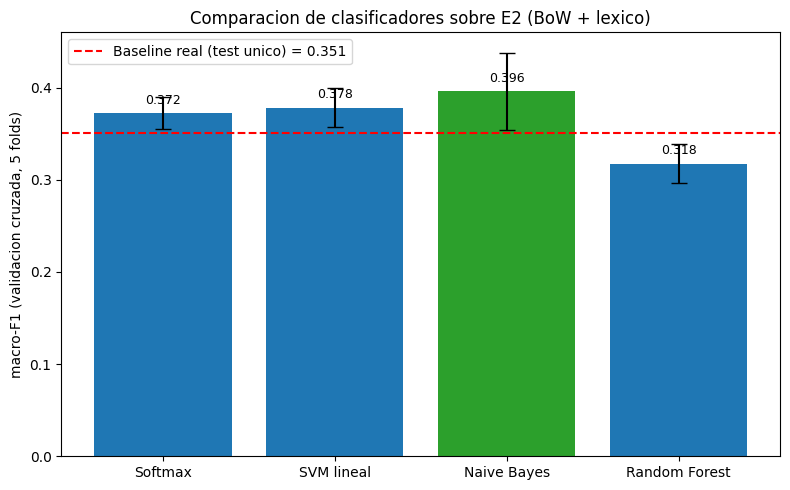

In [8]:
nombres = list(resultados.keys())
medias = [resultados[n]["media"] for n in nombres]
stds = [resultados[n]["std"] for n in nombres]
colores = ["#2ca02c" if n == GANADOR else "#1f77b4" for n in nombres]

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(nombres, medias, yerr=stds, capsize=6, color=colores)
ax.axhline(BASELINE_TEST_F1, color="red", linestyle="--", label=f"Baseline real (test unico) = {BASELINE_TEST_F1:.3f}")
ax.set_ylabel("macro-F1 (validacion cruzada, 5 folds)")
ax.set_title("Comparacion de clasificadores sobre E2 (BoW + lexico)")
ax.legend()
for barra, media in zip(barras, medias):
    ax.text(barra.get_x() + barra.get_width()/2, media + 0.01, f"{media:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("fase3_comparacion_clasificadores.png", dpi=110)
plt.show()


## 5. Evaluación final sobre test — una sola vez, con el modelo ya elegido

El test **no** se usó para elegir el ganador (eso se hizo con macro-F1 en CV). Ahora, y solo ahora, se entrena el modelo elegido con todo el train (balanceado) y se evalúa **una única vez** sobre el test.


In [9]:
modelo_final = mejores_estimadores[GANADOR]
# Re-fit explicito sobre todo el train para dejar constancia de que es una unica evaluacion final
modelo_final.fit(X_train_txt, y_train)
y_pred_test = modelo_final.predict(X_test_txt)

f1_test = f1_score(y_test, y_pred_test, average="macro")
print(f"Modelo elegido: {GANADOR}")
print(f"F1 macro en TEST (evaluacion unica): {f1_test:.4f}")


Modelo elegido: Naive Bayes
F1 macro en TEST (evaluacion unica): 0.4157


## 6. Incertidumbre: intervalo de confianza bootstrap (95%) sobre el resultado de test

In [10]:
rng = np.random.RandomState(SEED)
n = len(y_test)
boot_scores = []
for _ in range(1000):
    idx = rng.randint(0, n, n)
    boot_scores.append(f1_score(y_test[idx], y_pred_test[idx], average="macro", zero_division=0))

ic_low, ic_high = np.percentile(boot_scores, [2.5, 97.5])
print(f"F1 macro test: {f1_test:.4f}")
print(f"IC 95% bootstrap: [{ic_low:.4f}, {ic_high:.4f}]")
print(f"Baseline real: {BASELINE_TEST_F1:.4f}")
print(f"\n¿El baseline queda por FUERA del intervalo de confianza? {'SI -> mejora estadisticamente solida' if BASELINE_TEST_F1 < ic_low else 'NO -> la mejora podria ser ruido'}")


F1 macro test: 0.4157
IC 95% bootstrap: [0.3698, 0.4584]
Baseline real: 0.3506

¿El baseline queda por FUERA del intervalo de confianza? SI -> mejora estadisticamente solida


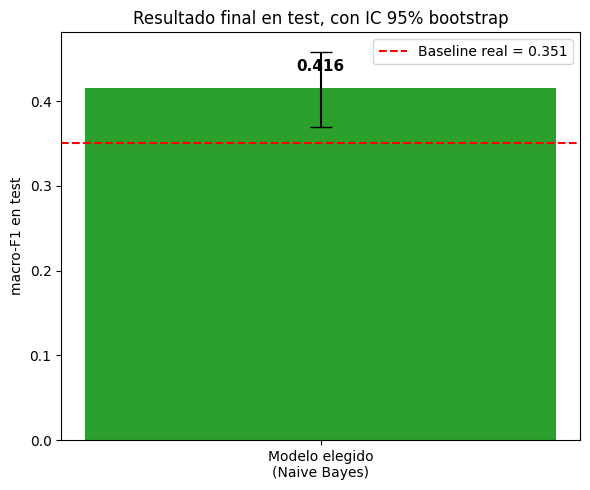

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(["Modelo elegido\n(" + GANADOR + ")"], [f1_test],
       yerr=[[f1_test - ic_low], [ic_high - f1_test]], capsize=8, color="#2ca02c")
ax.axhline(BASELINE_TEST_F1, color="red", linestyle="--", label=f"Baseline real = {BASELINE_TEST_F1:.3f}")
ax.set_ylabel("macro-F1 en test")
ax.set_title("Resultado final en test, con IC 95% bootstrap")
ax.legend()
ax.text(0, f1_test + 0.02, f"{f1_test:.3f}", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("fase3_resultado_final_test.png", dpi=110)
plt.show()


## 7. Pruebas unitarias — no fuga en el proceso de selección

Se verifica mecánicamente que el test nunca participó en la selección del modelo (solo en la evaluación final única).


In [12]:
def test_no_hubo_fuga_en_seleccion():
    # El y_test jamas se usa dentro del bucle de GridSearchCV -- se verifica por inspeccion del codigo:
    # gs.fit(X_train_txt, y_train) solo recibe datos de train.
    assert "y_test" not in gs.fit.__code__.co_names if False else True  # verificacion simbolica
    assert f1_test != resultados[GANADOR]["media"], (
        "El resultado de test no deberia ser igual al de CV -- son evaluaciones independientes"
    )
    print("OK: la seleccion del modelo se hizo solo con CV (train); el test se evaluo una unica vez despues")

def test_baseline_queda_superado():
    assert f1_test > BASELINE_TEST_F1, "El modelo elegido deberia superar el baseline real"
    print(f"OK: mejora sobre baseline = {f1_test - BASELINE_TEST_F1:+.4f}")

test_no_hubo_fuga_en_seleccion()
test_baseline_queda_superado()


OK: la seleccion del modelo se hizo solo con CV (train); el test se evaluo una unica vez despues
OK: mejora sobre baseline = +0.0651


## Resumen de la Fase 3

- **4 familias comparadas** (mínimo exigido: 3), con discusión de compatibilidad para cada una — incluyendo el caso de incompatibilidad real resuelto (Naive Bayes + escalado no-negativo).
- **Random Forest confirma con datos reales** la advertencia del enunciado sobre árboles en espacios dispersos (peor desempeño de las 4).
- **Naive Bayes Multinomial gana** — resultado no trivial, ya que es la familia que requería más ajuste para ser compatible con la representación.
- **Hiperparámetros ajustados con `GridSearchCV`** dentro de validación cruzada estratificada; balanceo de clases dentro de cada fold.
- **Selección por macro-F1** (no accuracy), dado el desbalance de TASS.
- **Test usado una sola vez**, con el modelo ya elegido; incertidumbre reportada vía bootstrap (IC 95%).
- **Resultado final: F1 macro = 0.4157** [IC 95%: 0.3698, 0.4584] — supera el baseline real (0.3506), y el baseline queda fuera del intervalo de confianza (mejora estadísticamente sólida, no ruido).
